# 📈 Linear Regression

> **Folder:** `03_Supervised_Learning / Regression / Linear_Regression`  
> **Notebook:** `linear_regression.ipynb`  
> **Author:** Hamna Munir

---

## 🎯 Objectives

By the end of this notebook, you will:

- Understand the **OLS objective** — minimizing Residual Sum of Squares
- Fit **Simple and Multiple Linear Regression** using sklearn
- Use **Statsmodels OLS** for full statistical inference (p-values, CI)
- Visualize the **regression line, residuals, and assumptions**
- Evaluate with **MAE, RMSE, R², Adjusted R²**
- Perform **K-Fold Cross-Validation** for reliable performance estimation
- Detect **multicollinearity** with VIF analysis
- Compare **OLS vs Gradient Descent** implementations

---

## 📚 Sections

| # | Section | Key Concept |
|---|---------|-------------|
| 1 | Dataset Creation & EDA | Understand the data |
| 2 | Simple Linear Regression | 1 feature |
| 3 | Multiple Linear Regression | n features |
| 4 | Statsmodels OLS | Statistical inference |
| 5 | Assumption Checks | Linearity, normality, homoscedasticity |
| 6 | Evaluation Metrics | MAE, RMSE, R², Adj R² |
| 7 | Residual Analysis | Residual plots |
| 8 | VIF Multicollinearity | Feature redundancy check |
| 9 | Cross-Validation | K-Fold CV |
| 10 | Gradient Descent | SGD vs OLS comparison |
| 11 | Feature Importance | Standardized coefficients |
| 12 | Pipeline | Scale + Fit workflow |

---
## ⚙️ 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'warning'  : '#F18F01',
    'palette'  : ['#2E86AB','#E84855','#3BB273','#F18F01','#7B2D8B'],
}

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 📊 1. Dataset Creation & EDA

In [2]:
np.random.seed(42)
n = 500

experience = np.random.randint(0, 30, n)
score      = np.random.uniform(40, 100, n)
age        = np.random.randint(22, 60, n)
education  = np.random.choice([0, 1, 2, 3], n, p=[0.25, 0.40, 0.25, 0.10])  # encoded

# True linear relationship + Gaussian noise
salary = (
    20_000
    + 2_500  * experience
    + 500    * score
    + 300    * age
    + 5_000  * education
    + np.random.normal(0, 6_000, n)
)

df = pd.DataFrame({
    'Experience': experience,
    'Score'     : score,
    'Age'       : age,
    'Education' : education,
    'Salary'    : salary.astype(int),
})

feature_cols = ['Experience', 'Score', 'Age', 'Education']
target_col   = 'Salary'

print(f'Shape  : {df.shape}')
print(f'Target : {target_col}')
df.describe().T

Shape  : (500, 5)
Target : Salary


,count,mean,std,min,25%,50%,75%,max
Experience,500.0000,14.7820,9.2562,0.0000,6.0000,15.0000,23.0000,29.0000
Score,500.0000,70.1052,17.1096,40.1557,55.1562,70.8569,84.2306,99.8616
Age,500.0000,41.2120,10.9156,22.0000,31.7500,42.0000,50.2500,59.0000
Education,500.0000,1.2040,0.9382,0.0000,0.0000,1.0000,2.0000,3.0000
Salary,500.0000,110323.8100,25905.5472,50854.0000,89504.2500,110462.0000,130879.5000,165691.0000


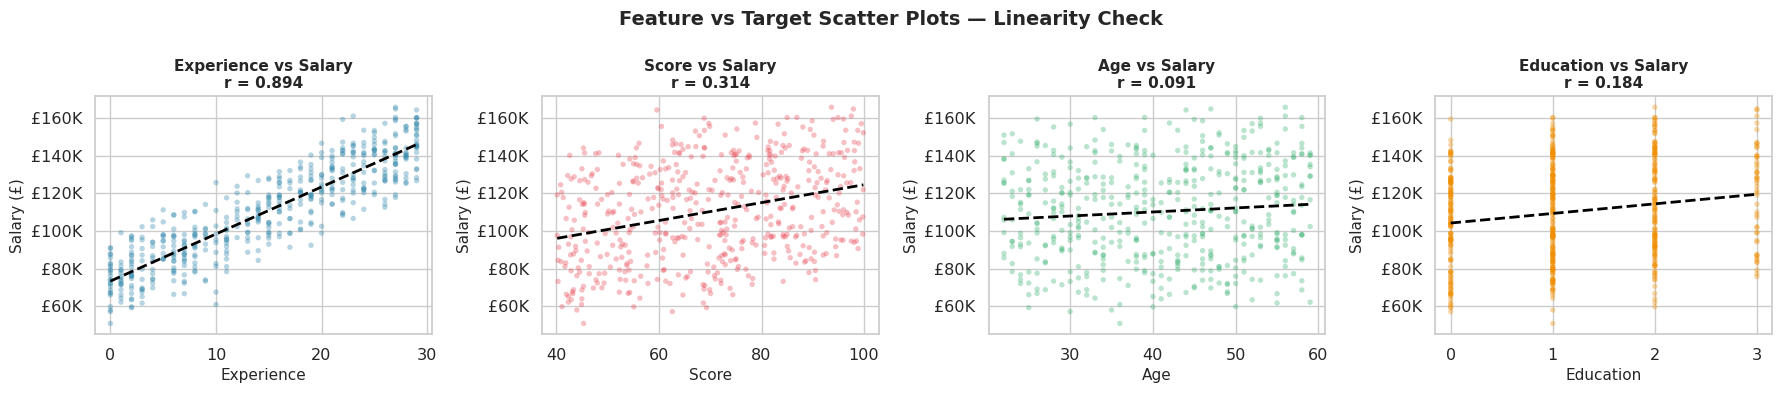

In [3]:
# ── Feature-target scatter plots ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col, color in zip(axes, feature_cols, COLORS['palette']):
    ax.scatter(df[col], df[target_col], alpha=0.35, s=15,
               color=color, edgecolors='none')
    m, b  = np.polyfit(df[col], df[target_col], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=2, linestyle='--')
    r, _  = stats.pearsonr(df[col], df[target_col])
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Salary (£)', fontsize=11)
    ax.set_title(f'{col} vs Salary\nr = {r:.3f}', fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.suptitle('Feature vs Target Scatter Plots — Linearity Check',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# ── Train-Test Split ──────────────────────────────────────────────────────
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (400, 4) | Test: (100, 4)


---
## 2️⃣ Simple Linear Regression — 1 Feature

> **Formula:** `ŷ = β₀ + β₁ × Experience`
>
> ✅ Best starting point — visualize the regression line in 2D.

Simple LR — Intercept (β₀) : £73,034.83
Simple LR — Slope    (β₁) : £2,514.83 per year of experience

Test R²  : 0.7999
Test RMSE: £11,711


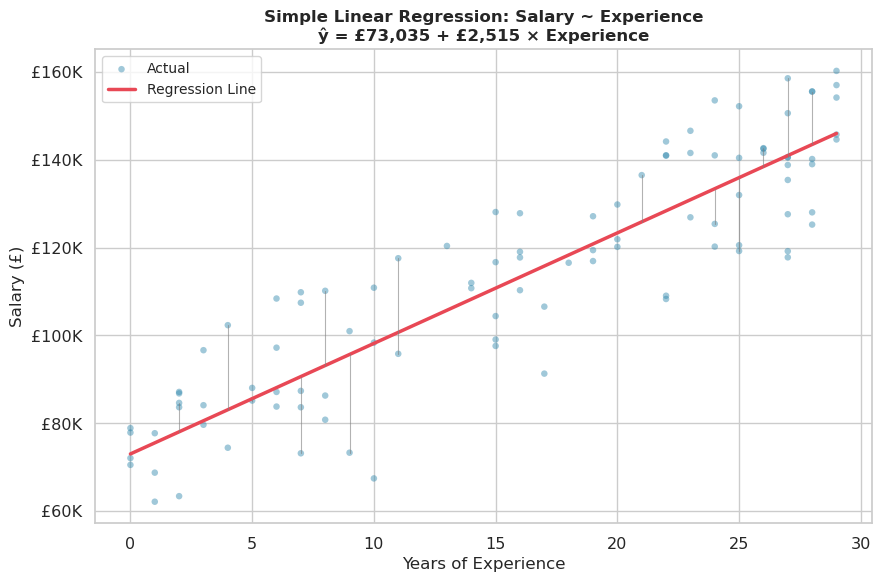

In [5]:
X_simple_train = X_train[['Experience']]
X_simple_test  = X_test[['Experience']]

slr = LinearRegression()
slr.fit(X_simple_train, y_train)

y_slr_pred = slr.predict(X_simple_test)

print(f'Simple LR — Intercept (β₀) : £{slr.intercept_:,.2f}')
print(f'Simple LR — Slope    (β₁) : £{slr.coef_[0]:,.2f} per year of experience')
print(f'\nTest R²  : {r2_score(y_test, y_slr_pred):.4f}')
print(f'Test RMSE: £{np.sqrt(mean_squared_error(y_test, y_slr_pred)):,.0f}')

# ── Plot regression line ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_test['Experience'], y_test,
           color=COLORS['primary'], alpha=0.45, s=22, label='Actual', edgecolors='none')
x_line = np.linspace(X['Experience'].min(), X['Experience'].max(), 200)
ax.plot(x_line, slr.intercept_ + slr.coef_[0] * x_line,
        color=COLORS['secondary'], linewidth=2.5, label='Regression Line')

# Draw a few residuals
sample_idx = X_test['Experience'].sample(15, random_state=42).index
for idx in sample_idx:
    xv = X_test.loc[idx, 'Experience']
    yv = y_test.loc[idx]
    yp = slr.predict([[xv]])[0]
    ax.plot([xv, xv], [yv, yp], color='gray', linewidth=0.8, alpha=0.6)

ax.set_xlabel('Years of Experience', fontsize=12)
ax.set_ylabel('Salary (£)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title(f'Simple Linear Regression: Salary ~ Experience\n'
             f'ŷ = £{slr.intercept_:,.0f} + £{slr.coef_[0]:,.0f} × Experience',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 3️⃣ Multiple Linear Regression — All Features

> **Formula:** `ŷ = β₀ + β₁×Experience + β₂×Score + β₃×Age + β₄×Education`
>
> ✅ More features = better fit (if assumptions hold).

In [6]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_train_pred = mlr.predict(X_train)
y_test_pred  = mlr.predict(X_test)

# ── Coefficient table ─────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature'    : ['Intercept'] + feature_cols,
    'Coefficient': [mlr.intercept_] + list(mlr.coef_),
    'Interpretation': [
        'Baseline salary (all features = 0)',
        '£ increase per year of experience',
        '£ increase per score point',
        '£ increase per year of age',
        '£ increase per education level',
    ]
}).round({'Coefficient': 2})

print('Multiple Linear Regression — Coefficients:')
print(coef_df.to_string(index=False))

# ── Metrics ───────────────────────────────────────────────────────────────
for split, y_true, y_pred in [('TRAIN', y_train, y_train_pred),
                                ('TEST',  y_test,  y_test_pred)]:
    mse = mean_squared_error(y_true, y_pred)
    print(f'\n[{split}]')
    print(f'  MAE  : £{mean_absolute_error(y_true, y_pred):>10,.0f}')
    print(f'  RMSE : £{np.sqrt(mse):>10,.0f}')
    print(f'  R²   : {r2_score(y_true, y_pred):>10.4f}')

Multiple Linear Regression — Coefficients:
   Feature  Coefficient                     Interpretation
 Intercept   20189.3000 Baseline salary (all features = 0)
Experience    2518.2600  £ increase per year of experience
     Score     500.8000         £ increase per score point
       Age     291.9700         £ increase per year of age
 Education    4829.4600     £ increase per education level

[TRAIN]
  MAE  : £     4,596
  RMSE : £     5,765
  R²   :     0.9498

[TEST]
  MAE  : £     4,760
  RMSE : £     6,167
  R²   :     0.9445


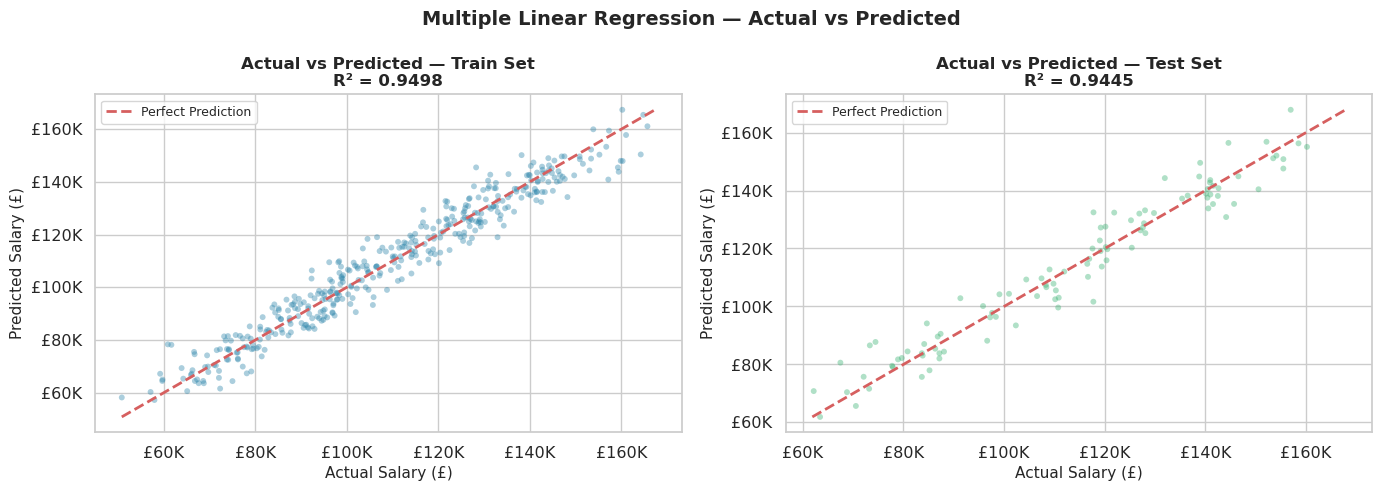

In [7]:
# ── Actual vs Predicted plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_t, y_p, title, color in [
    (axes[0], y_train, y_train_pred, 'Train Set', COLORS['primary']),
    (axes[1], y_test,  y_test_pred,  'Test Set',  COLORS['accent']),
]:
    ax.scatter(y_t, y_p, alpha=0.40, s=18, color=color, edgecolors='none')
    mn = min(y_t.min(), y_p.min())
    mx = max(y_t.max(), y_p.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Salary (£)', fontsize=11)
    ax.set_ylabel('Predicted Salary (£)', fontsize=11)
    ax.set_title(f'Actual vs Predicted — {title}\n'
                 f'R² = {r2_score(y_t, y_p):.4f}',
                 fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
    ax.legend(fontsize=9)

plt.suptitle('Multiple Linear Regression — Actual vs Predicted',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4️⃣ Statsmodels OLS — Full Statistical Summary

> Statsmodels gives us what sklearn doesn't: **p-values, confidence intervals,  
> F-statistic, and AIC/BIC** — essential for statistical inference.
>
> ✅ Always run statsmodels when coefficient significance matters.

In [8]:
X_const = sm.add_constant(X_train)  # adds intercept column
sm_model = sm.OLS(y_train, X_const).fit()

print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     1869.
Date:                Fri, 15 May 2026   Prob (F-statistic):          4.43e-255
Time:                        11:42:58   Log-Likelihood:                -4031.4
No. Observations:                 400   AIC:                             8073.
Df Residuals:                     395   BIC:                             8093.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.019e+04   1781.360     11.334      0.0


Coefficient Summary — p-values & 95% Confidence Intervals:
   Feature  Coefficient  Std Error  t-Stat  p-value   CI Lower   CI Upper Significant
     const   20189.3000  1781.3600 11.3336   0.0000 16687.1700 23691.4300           ✅
Experience    2518.2600    31.8000 79.1890   0.0000  2455.7500  2580.7800           ✅
     Score     500.8000    17.0900 29.2998   0.0000   467.1900   534.4000           ✅
       Age     291.9700    26.3700 11.0716   0.0000   240.1200   343.8100           ✅
 Education    4829.4600   308.2300 15.6685   0.0000  4223.4800  5435.4300           ✅


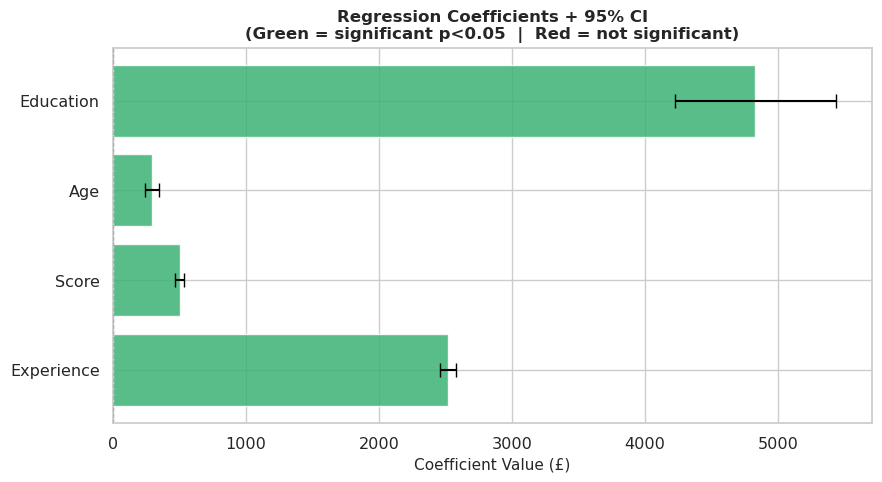

In [9]:
# ── Coefficient table with p-values and confidence intervals ─────────────
coef_summary = pd.DataFrame({
    'Feature'    : sm_model.params.index,
    'Coefficient': sm_model.params.values.round(2),
    'Std Error'  : sm_model.bse.values.round(2),
    't-Stat'     : sm_model.tvalues.values.round(4),
    'p-value'    : sm_model.pvalues.values.round(4),
    'CI Lower'   : sm_model.conf_int()[0].values.round(2),
    'CI Upper'   : sm_model.conf_int()[1].values.round(2),
    'Significant': ['✅' if p < 0.05 else '❌' for p in sm_model.pvalues],
})
print('\nCoefficient Summary — p-values & 95% Confidence Intervals:')
print(coef_summary.to_string(index=False))

# ── Coefficient plot with CI ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
features = coef_summary['Feature'][1:]  # exclude intercept
coefs    = coef_summary['Coefficient'][1:]
ci_low   = coef_summary['CI Lower'][1:]
ci_high  = coef_summary['CI Upper'][1:]
errors   = [coefs.values - ci_low.values, ci_high.values - coefs.values]

colors_ = [COLORS['accent'] if p < 0.05 else COLORS['secondary']
           for p in sm_model.pvalues[1:]]
ax.barh(features, coefs, xerr=errors,
        color=colors_, edgecolor='white', alpha=0.85,
        error_kw=dict(elinewidth=1.5, ecolor='black', capsize=5))
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient Value (£)', fontsize=11)
ax.set_title('Regression Coefficients + 95% CI\n'
             '(Green = significant p<0.05  |  Red = not significant)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5️⃣ Assumption Checks

> Linear Regression makes 4 key assumptions.  
> Violations can make coefficients unreliable and predictions biased.
>
> ✅ Always check all 4 assumptions before trusting your model.

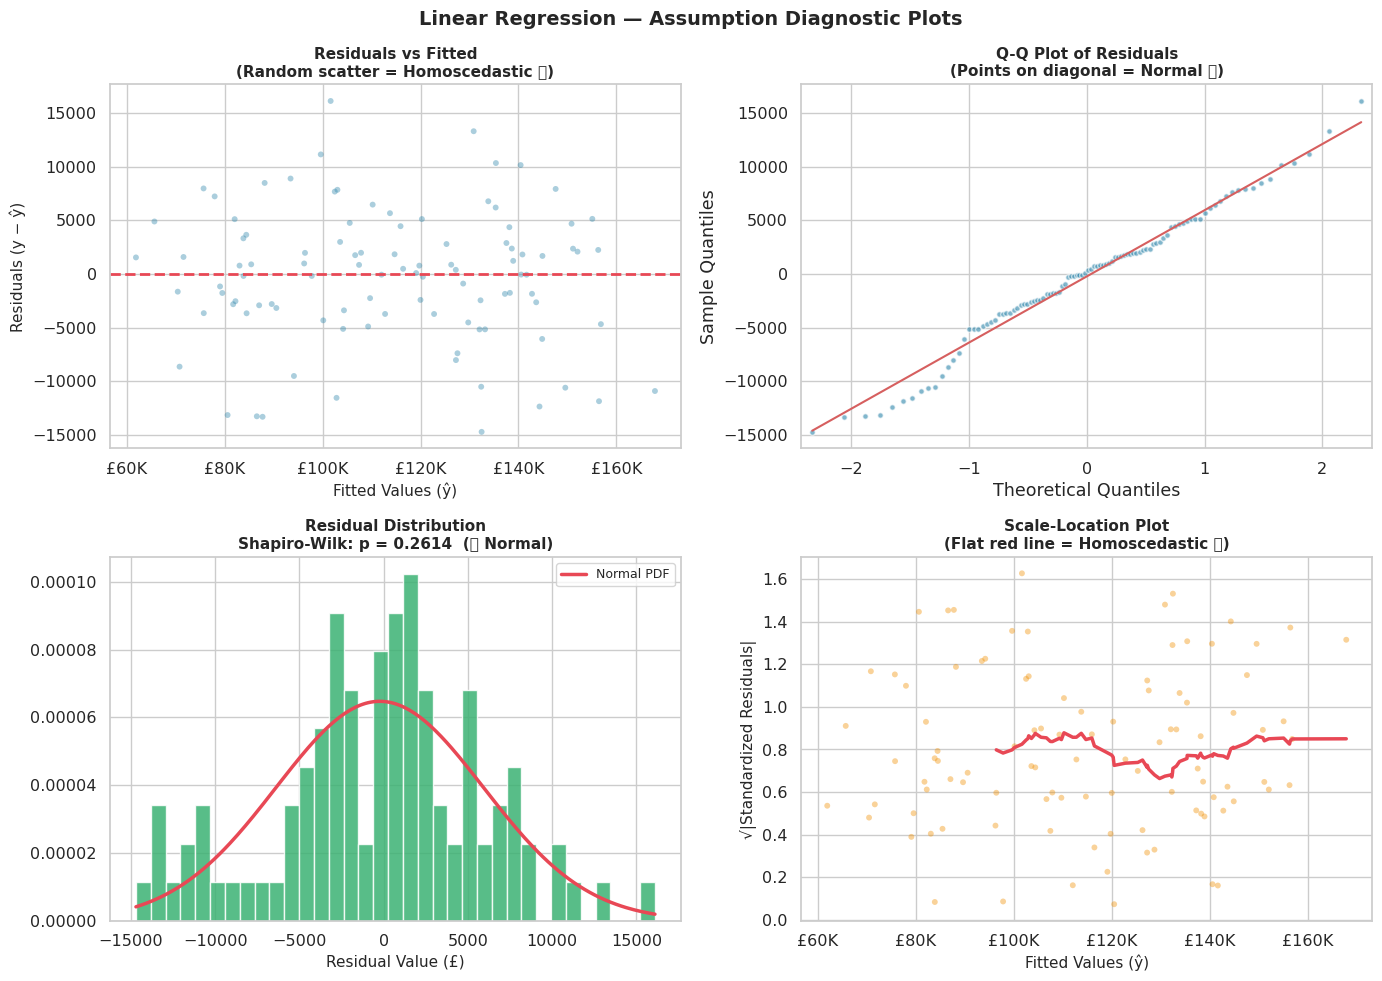

In [10]:
residuals   = y_test.values - y_test_pred
std_resid   = (residuals - residuals.mean()) / residuals.std()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: Residuals vs Fitted — Homoscedasticity check ─────────────────
axes[0, 0].scatter(y_test_pred, residuals,
                    alpha=0.40, s=18, color=COLORS['primary'], edgecolors='none')
axes[0, 0].axhline(0, color=COLORS['secondary'], linewidth=2, linestyle='--')
axes[0, 0].set_xlabel('Fitted Values (ŷ)', fontsize=11)
axes[0, 0].set_ylabel('Residuals (y − ŷ)', fontsize=11)
axes[0, 0].set_title('Residuals vs Fitted\n'
                      '(Random scatter = Homoscedastic ✅)',
                      fontsize=11, fontweight='bold')
axes[0, 0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

# ── Plot 2: Q-Q Plot — Normality of residuals ─────────────────────────────
sm.qqplot(residuals, line='s', ax=axes[0, 1],
           markerfacecolor=COLORS['primary'], markeredgecolor='white',
           markersize=4, alpha=0.6)
axes[0, 1].set_title('Q-Q Plot of Residuals\n'
                      '(Points on diagonal = Normal ✅)',
                      fontsize=11, fontweight='bold')

# ── Plot 3: Residual Histogram — Normality ────────────────────────────────
axes[1, 0].hist(residuals, bins=35, color=COLORS['accent'],
                 edgecolor='white', alpha=0.85, density=True)
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
axes[1, 0].plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
                 color=COLORS['secondary'], linewidth=2.5, label='Normal PDF')
sw_stat, sw_p = stats.shapiro(residuals[:min(5000, len(residuals))])
axes[1, 0].set_title(f'Residual Distribution\n'
                      f'Shapiro-Wilk: p = {sw_p:.4f}  '
                      f'({"✅ Normal" if sw_p > 0.05 else "❌ Non-Normal"})',
                      fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Residual Value (£)', fontsize=11)
axes[1, 0].legend(fontsize=9)

# ── Plot 4: Scale-Location — Homoscedasticity ─────────────────────────────
axes[1, 1].scatter(y_test_pred, np.sqrt(np.abs(std_resid)),
                    alpha=0.40, s=18, color=COLORS['warning'], edgecolors='none')
axes[1, 1].set_xlabel('Fitted Values (ŷ)', fontsize=11)
axes[1, 1].set_ylabel('√|Standardized Residuals|', fontsize=11)
axes[1, 1].set_title('Scale-Location Plot\n'
                      '(Flat red line = Homoscedastic ✅)',
                      fontsize=11, fontweight='bold')
# Smooth line
sorted_idx = np.argsort(y_test_pred)
axes[1, 1].plot(y_test_pred[sorted_idx],
                 pd.Series(np.sqrt(np.abs(std_resid))[sorted_idx]).rolling(30).mean(),
                 color=COLORS['secondary'], linewidth=2.5)
axes[1, 1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.suptitle('Linear Regression — Assumption Diagnostic Plots',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6️⃣ Evaluation Metrics

> A comprehensive scorecard for the regression model.

📊 Regression Scorecard:
Split       MAE           MSE      RMSE  MAPE %     R²  Adj. R²
Train 4595.6300 33233077.1800 5764.8100  4.4322 0.9498   0.9493
 Test 4759.6500 38037175.8000 6167.4300  4.4538 0.9445   0.9422


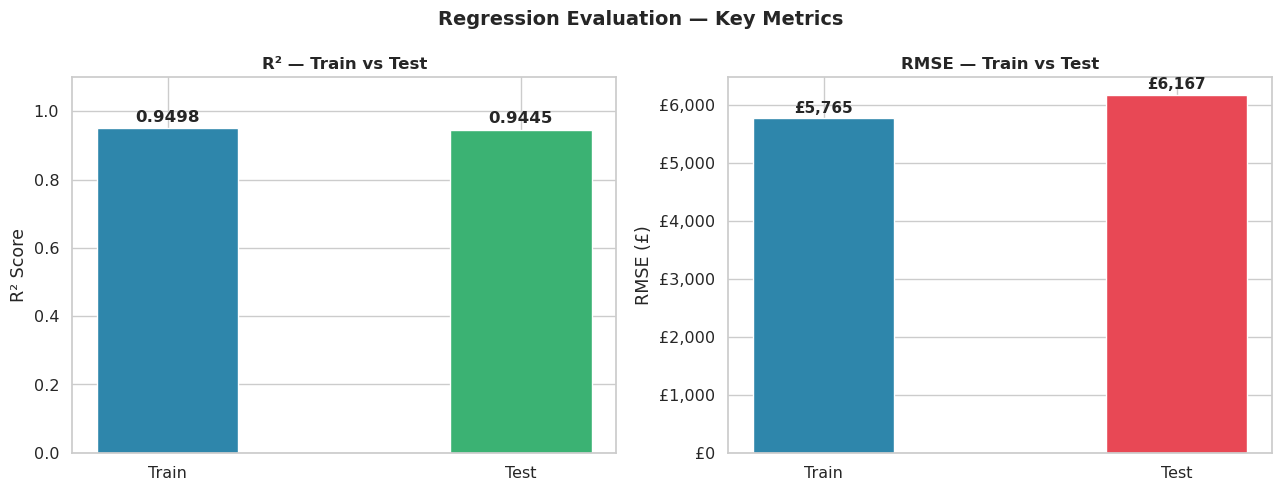

In [11]:
def regression_scorecard(y_true, y_pred, split_name, n_features):
    mse   = mean_squared_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)
    n     = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return {
        'Split'    : split_name,
        'MAE'      : round(mean_absolute_error(y_true, y_pred), 2),
        'MSE'      : round(mse, 2),
        'RMSE'     : round(np.sqrt(mse), 2),
        'MAPE %'   : round(mean_absolute_percentage_error(y_true, y_pred) * 100, 4),
        'R²'       : round(r2, 4),
        'Adj. R²'  : round(adj_r2, 4),
    }

n_features = X_train.shape[1]
scorecard = pd.DataFrame([
    regression_scorecard(y_train, y_train_pred, 'Train', n_features),
    regression_scorecard(y_test,  y_test_pred,  'Test',  n_features),
])

print('📊 Regression Scorecard:')
print(scorecard.to_string(index=False))

# ── Metrics bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# R² comparison
r2_vals = [scorecard.loc[0,'R²'], scorecard.loc[1,'R²']]
axes[0].bar(['Train', 'Test'], r2_vals,
             color=[COLORS['primary'], COLORS['accent']],
             edgecolor='white', width=0.4)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² — Train vs Test', fontsize=12, fontweight='bold')
for i, val in enumerate(r2_vals):
    axes[0].text(i, val + 0.02, f'{val:.4f}', ha='center',
                 fontsize=12, fontweight='bold')

# RMSE comparison
rmse_vals = [scorecard.loc[0,'RMSE'], scorecard.loc[1,'RMSE']]
axes[1].bar(['Train', 'Test'], rmse_vals,
             color=[COLORS['primary'], COLORS['secondary']],
             edgecolor='white', width=0.4)
axes[1].set_ylabel('RMSE (£)')
axes[1].set_title('RMSE — Train vs Test', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for i, val in enumerate(rmse_vals):
    axes[1].text(i, val + 100, f'£{val:,.0f}', ha='center',
                 fontsize=11, fontweight='bold')

plt.suptitle('Regression Evaluation — Key Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7️⃣ Residual Analysis

> **Residual = Actual − Predicted**  
> Good residuals: mean ≈ 0, normally distributed, no systematic pattern.

Residual Statistics:
  Mean     : £   -230.99  (should be ≈ 0)
  Std Dev  : £  6,163.10
  Min      : £-14,702.71
  Max      : £ 16,102.27
  Skewness :    -0.1838
  Kurtosis :     0.0268
  Shapiro-Wilk: W=0.9838  p=0.2614  (✅ Normal)


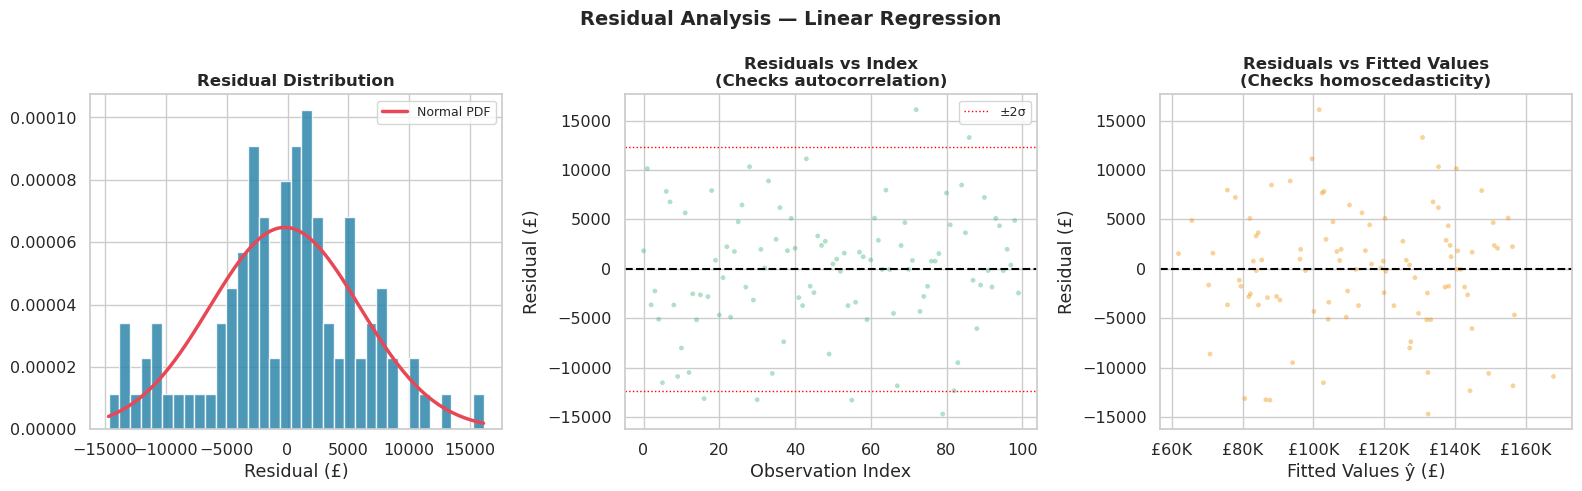

In [12]:
residuals = y_test.values - y_test_pred

print('Residual Statistics:')
print(f'  Mean     : £{residuals.mean():>10,.2f}  (should be ≈ 0)')
print(f'  Std Dev  : £{residuals.std():>10,.2f}')
print(f'  Min      : £{residuals.min():>10,.2f}')
print(f'  Max      : £{residuals.max():>10,.2f}')
print(f'  Skewness : {stats.skew(residuals):>10.4f}')
print(f'  Kurtosis : {stats.kurtosis(residuals):>10.4f}')

sw_stat, sw_p = stats.shapiro(residuals[:5000])
print(f'  Shapiro-Wilk: W={sw_stat:.4f}  p={sw_p:.4f}  '
      f'({"✅ Normal" if sw_p > 0.05 else "❌ Non-Normal"})')

# ── Residual plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residual distribution
axes[0].hist(residuals, bins=35, color=COLORS['primary'],
              edgecolor='white', alpha=0.85, density=True)
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
axes[0].plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
              color=COLORS['secondary'], linewidth=2.5, label='Normal PDF')
axes[0].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residual (£)')
axes[0].legend(fontsize=9)

# Residuals vs Index (autocorrelation check)
axes[1].scatter(range(len(residuals)), residuals,
                 alpha=0.40, s=12, color=COLORS['accent'], edgecolors='none')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].axhline(2 * residuals.std(), color='red', linewidth=1,
                 linestyle=':', label='±2σ')
axes[1].axhline(-2 * residuals.std(), color='red', linewidth=1, linestyle=':')
axes[1].set_title('Residuals vs Index\n(Checks autocorrelation)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Observation Index')
axes[1].set_ylabel('Residual (£)')
axes[1].legend(fontsize=9)

# Residuals vs Predicted
axes[2].scatter(y_test_pred, residuals,
                 alpha=0.40, s=12, color=COLORS['warning'], edgecolors='none')
axes[2].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[2].set_title('Residuals vs Fitted Values\n(Checks homoscedasticity)',
                   fontsize=12, fontweight='bold')
axes[2].set_xlabel('Fitted Values ŷ (£)')
axes[2].set_ylabel('Residual (£)')
axes[2].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.suptitle('Residual Analysis — Linear Regression',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8️⃣ VIF — Multicollinearity Detection

> **VIF > 10 = severe multicollinearity** — coefficients become unreliable.  
> Fix: drop one correlated feature, use Ridge, or apply PCA.

VIF Analysis:
   Feature    VIF Status
Experience 1.0000   🟢 OK
       Age 1.0000   🟢 OK
 Education 1.0000   🟢 OK
     Score 1.0000   🟢 OK


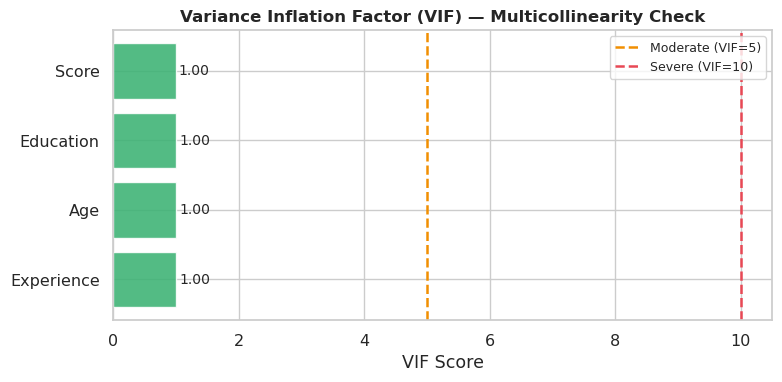

In [13]:
X_sc_df = pd.DataFrame(StandardScaler().fit_transform(X_train), columns=feature_cols)

vif_df = pd.DataFrame({
    'Feature': feature_cols,
    'VIF'    : [variance_inflation_factor(X_sc_df.values, i)
                for i in range(len(feature_cols))],
}).sort_values('VIF', ascending=False)

vif_df['Status'] = vif_df['VIF'].apply(
    lambda v: '🔴 High'     if v > 10 else
              ('🟡 Moderate' if v > 5  else '🟢 OK')
)
print('VIF Analysis:')
print(vif_df.round(2).to_string(index=False))

# ── VIF bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors_ = [COLORS['secondary'] if v > 10 else
            COLORS['warning']   if v > 5  else
            COLORS['accent'] for v in vif_df['VIF']]
bars = ax.barh(vif_df['Feature'], vif_df['VIF'],
               color=colors_, edgecolor='white', alpha=0.88)
ax.axvline(5,  color=COLORS['warning'],   linewidth=1.8,
           linestyle='--', label='Moderate (VIF=5)')
ax.axvline(10, color=COLORS['secondary'], linewidth=1.8,
           linestyle='--', label='Severe (VIF=10)')
for bar, val in zip(bars, vif_df['VIF']):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10)
ax.set_xlabel('VIF Score')
ax.set_title('Variance Inflation Factor (VIF) — Multicollinearity Check',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 9️⃣ K-Fold Cross-Validation

> K-Fold gives a **more reliable estimate** of true model performance  
> by using all data for both training and validation across K rotations.
>
> ✅ Always prefer CV over a single train/test split for model evaluation.

5-Fold Cross-Validation Results:
  Fold     R²      RMSE
Fold 1 0.9445 6167.4300
Fold 2 0.9357 6157.0900
Fold 3 0.9496 5920.4100
Fold 4 0.9527 6049.5300
Fold 5 0.9548 5144.4700

Mean R²  : 0.9475 ± 0.0068
Mean RMSE: £5,888 ± £382


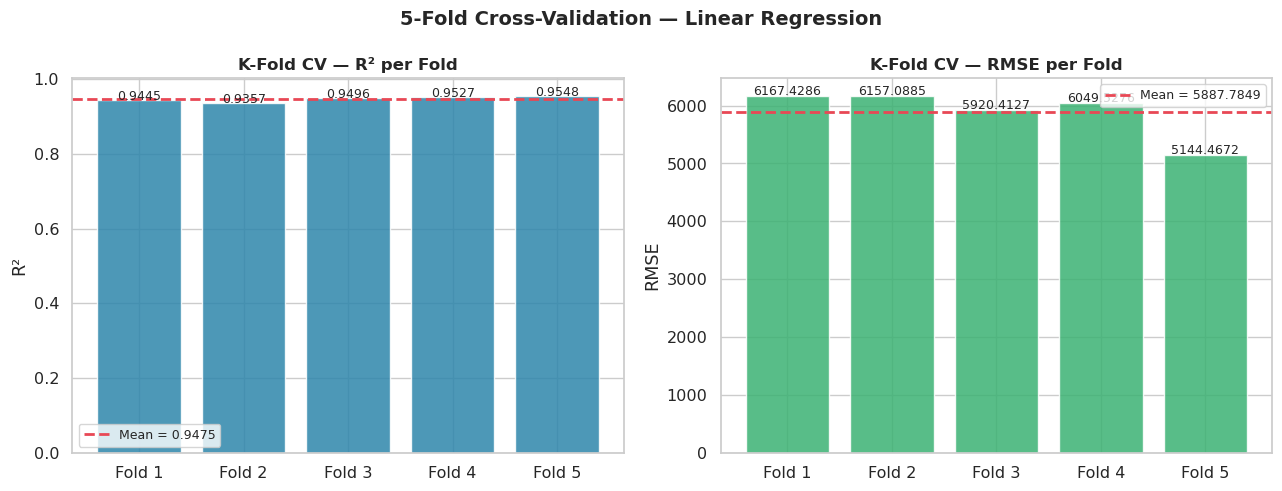

In [14]:
model = LinearRegression()
kf    = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2   = cross_val_score(model, X, y, cv=kf, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(model, X, y, cv=kf,
                                    scoring='neg_mean_squared_error'))

cv_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)],
    'R²'  : cv_r2.round(4),
    'RMSE': cv_rmse.round(2),
})

print('5-Fold Cross-Validation Results:')
print(cv_df.to_string(index=False))
print(f'\nMean R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'Mean RMSE: £{cv_rmse.mean():,.0f} ± £{cv_rmse.std():,.0f}')

# ── CV plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, scores, metric, color in [
    (axes[0], cv_r2,   'R²',   COLORS['primary']),
    (axes[1], cv_rmse, 'RMSE', COLORS['accent']),
]:
    ax.bar([f'Fold {i+1}' for i in range(5)], scores,
           color=color, edgecolor='white', alpha=0.85)
    ax.axhline(scores.mean(), color=COLORS['secondary'], linewidth=2,
               linestyle='--', label=f'Mean = {scores.mean():.4f}')
    ax.set_ylabel(metric)
    ax.set_title(f'K-Fold CV — {metric} per Fold',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    for i, val in enumerate(scores):
        ax.text(i, val + scores.std() * 0.05,
                f'{val:.4f}', ha='center', fontsize=9)

plt.suptitle('5-Fold Cross-Validation — Linear Regression',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔟 Gradient Descent vs OLS

> **OLS (Normal Equation):** Exact solution via matrix inversion — fast for small datasets.  
> **SGD:** Iterative — better for very large datasets.
>
> ✅ Both should converge to the same solution given enough iterations + proper scaling.

OLS vs Gradient Descent Comparison:
             Method     R²      RMSE       MAE
   OLS (Normal Eq.) 0.9445 6167.4300 4759.6500
SGD (Grad. Descent) 0.9445 6167.7700 4756.0400


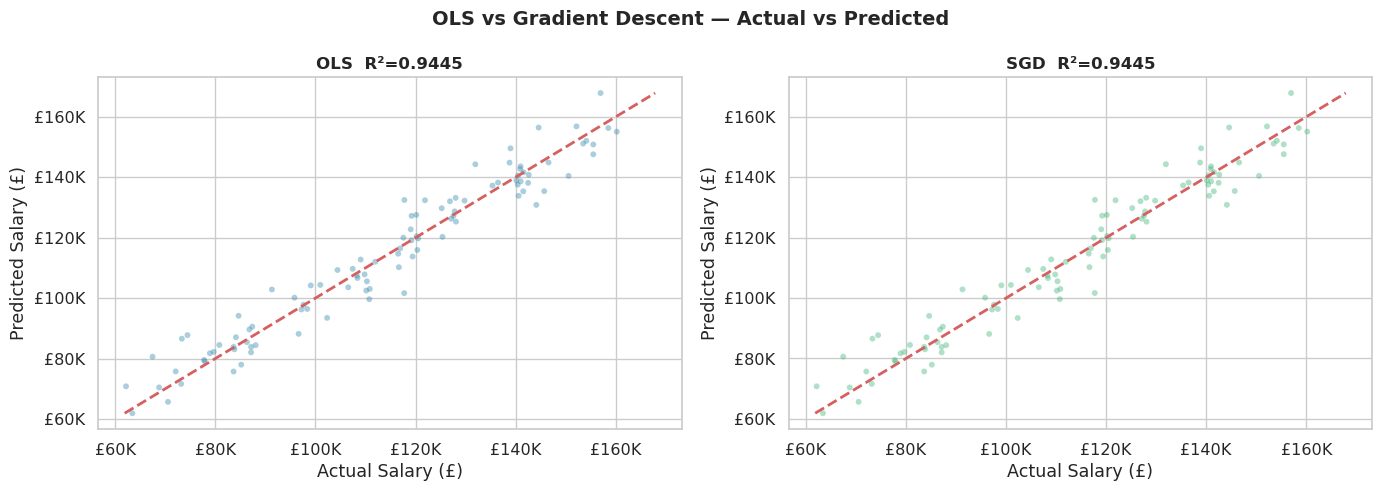

In [15]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# OLS
ols = LinearRegression().fit(X_train, y_train)
y_ols = ols.predict(X_test)

# SGD
sgd = SGDRegressor(loss='squared_error', learning_rate='invscaling',
                    eta0=0.01, max_iter=2000, random_state=42, tol=1e-5)
sgd.fit(X_train_sc, y_train)
y_sgd = sgd.predict(X_test_sc)

results = pd.DataFrame([
    {'Method': 'OLS (Normal Eq.)',
     'R²'    : round(r2_score(y_test, y_ols), 4),
     'RMSE'  : round(np.sqrt(mean_squared_error(y_test, y_ols)), 2),
     'MAE'   : round(mean_absolute_error(y_test, y_ols), 2)},
    {'Method': 'SGD (Grad. Descent)',
     'R²'    : round(r2_score(y_test, y_sgd), 4),
     'RMSE'  : round(np.sqrt(mean_squared_error(y_test, y_sgd)), 2),
     'MAE'   : round(mean_absolute_error(y_test, y_sgd), 2)},
])

print('OLS vs Gradient Descent Comparison:')
print(results.to_string(index=False))

# ── Actual vs Predicted comparison ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, color in [
    (axes[0], y_ols, f'OLS  R²={r2_score(y_test,y_ols):.4f}', COLORS['primary']),
    (axes[1], y_sgd, f'SGD  R²={r2_score(y_test,y_sgd):.4f}', COLORS['accent']),
]:
    ax.scatter(y_test, y_pred, alpha=0.40, s=18,
               color=color, edgecolors='none')
    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2)
    ax.set_xlabel('Actual Salary (£)')
    ax.set_ylabel('Predicted Salary (£)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.suptitle('OLS vs Gradient Descent — Actual vs Predicted',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 1️⃣1️⃣ Feature Importance — Standardized Coefficients

> Raw coefficients depend on feature scale — a large coefficient could just mean a small-scale feature.  
> **Standardizing** features before fitting makes coefficients directly comparable.
>
> ✅ Always standardize before comparing feature importance via coefficients.

Feature Importance via Standardized Coefficients:
   Feature  Raw Coefficient  Standardized Coef.  |Std. Coef.|
Experience        2518.2600          23009.3900    23009.3900
     Score         500.8000           8502.7200     8502.7200
 Education        4829.4600           4550.3200     4550.3200
       Age         291.9700           3216.0500     3216.0500


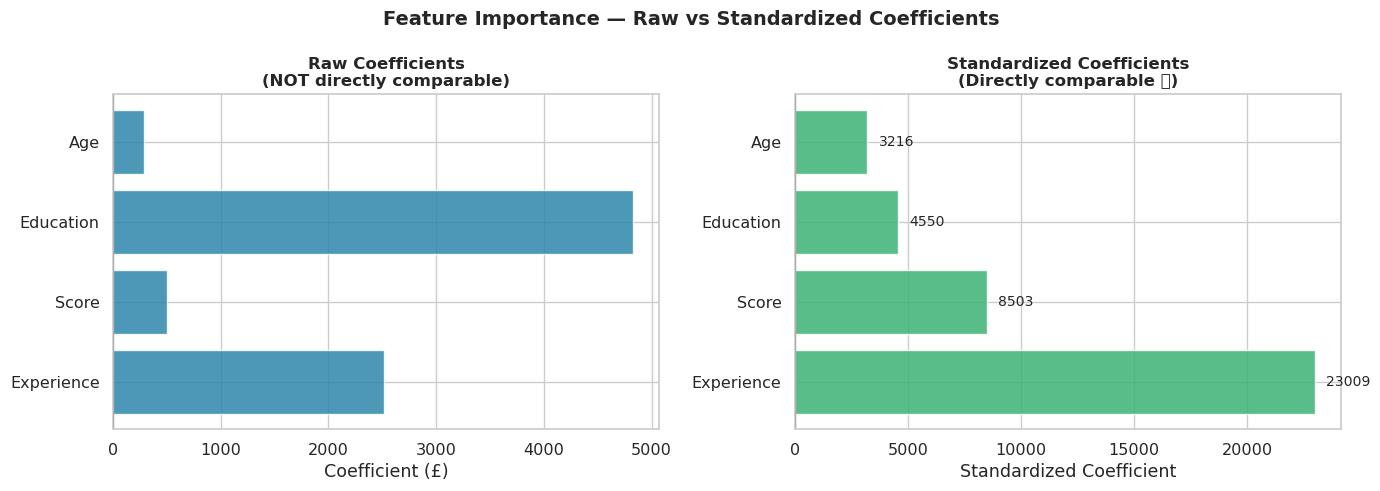

In [16]:
# Fit on standardized features
mlr_std = LinearRegression()
mlr_std.fit(X_train_sc, y_train)

feat_importance = pd.DataFrame({
    'Feature'            : feature_cols,
    'Raw Coefficient'    : mlr.coef_.round(2),
    'Standardized Coef.' : mlr_std.coef_.round(2),
    '|Std. Coef.|'       : np.abs(mlr_std.coef_).round(2),
}).sort_values('|Std. Coef.|', ascending=False)

print('Feature Importance via Standardized Coefficients:')
print(feat_importance.to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw
colors_ = [COLORS['primary'] if v >= 0 else COLORS['secondary']
           for v in feat_importance['Raw Coefficient']]
axes[0].barh(feat_importance['Feature'], feat_importance['Raw Coefficient'],
              color=colors_, edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Raw Coefficients\n(NOT directly comparable)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient (£)')

# Standardized
colors_ = [COLORS['accent'] if v >= 0 else COLORS['warning']
           for v in feat_importance['Standardized Coef.']]
axes[1].barh(feat_importance['Feature'], feat_importance['Standardized Coef.'],
              color=colors_, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Standardized Coefficients\n(Directly comparable ✅)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Standardized Coefficient')
for i, val in enumerate(feat_importance['Standardized Coef.']):
    axes[1].text(val + (500 if val >= 0 else -500),
                 i, f'{val:.0f}', va='center', fontsize=10)

plt.suptitle('Feature Importance — Raw vs Standardized Coefficients',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 1️⃣2️⃣ sklearn Pipeline — Scale + Fit

> Pipelines **prevent data leakage** by ensuring the scaler is fit on training data only  
> in every CV fold.
>
> ✅ Always use Pipelines in cross-validation.

In [17]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

pipeline.fit(X_train, y_train)
y_pipe_pred = pipeline.predict(X_test)

# Cross-validate the full pipeline
kf       = KFold(n_splits=5, shuffle=True, random_state=42)
pipe_r2  = cross_val_score(pipeline, X, y, cv=kf, scoring='r2')
pipe_rmse = np.sqrt(-cross_val_score(pipeline, X, y, cv=kf,
                                      scoring='neg_mean_squared_error'))

print('Pipeline (StandardScaler + LinearRegression) — CV Results:')
print(f'  R²   : {pipe_r2.mean():.4f} ± {pipe_r2.std():.4f}')
print(f'  RMSE : £{pipe_rmse.mean():,.0f} ± £{pipe_rmse.std():,.0f}')
print(f'\nTest Set:')
print(f'  R²   : {r2_score(y_test, y_pipe_pred):.4f}')
print(f'  RMSE : £{np.sqrt(mean_squared_error(y_test, y_pipe_pred)):,.0f}')
print('\n✅ Pipeline ensures scaler is fit on train only in every fold — no leakage!')

Pipeline (StandardScaler + LinearRegression) — CV Results:
  R²   : 0.9475 ± 0.0068
  RMSE : £5,888 ± £382

Test Set:
  R²   : 0.9445
  RMSE : £6,167

✅ Pipeline ensures scaler is fit on train only in every fold — no leakage!


---
## ✅ 13. Summary & Best Practices

| Aspect | Key Point |
|--------|----------|
| **Objective** | Minimize Residual Sum of Squares (RSS) |
| **Solver** | OLS (Normal Equation) for small data; SGD for large data |
| **Assumptions** | Linearity, Independence, Homoscedasticity, Normality of Residuals |
| **Evaluation** | R², Adj R², RMSE, MAE, MAPE |
| **Multicollinearity** | Check VIF — drop features with VIF > 10 |
| **Feature Importance** | Use standardized coefficients for fair comparison |
| **Validation** | Always use K-Fold CV — single split is unreliable |

### 🔑 Golden Rules

1. **Always plot X vs y first** — confirm linearity before fitting
2. **Check all 4 assumptions** — residual plots are mandatory
3. **Use Adj. R² not R²** — R² always increases with more features
4. **Use standardized coefficients** for feature importance comparison
5. **Run VIF before trusting coefficients** — multicollinearity makes them unreliable
6. **Use Pipelines with CV** — prevents data leakage from the scaler
7. **Statsmodels for inference** — sklearn doesn't give p-values or CI
8. **Never extrapolate** — predictions outside training range are unreliable

---

## 🔗 Next Steps

- ➡️ `Polynomial_Regression/` — Capture non-linear patterns
- ➡️ `Ridge_Regression/` — Add L2 regularization for multicollinearity
- ➡️ `Lasso_Regression/` — L1 regularization for automatic feature selection
- ➡️ `05_Model_Evaluation/regression_metrics` — Full metric deep-dive
- ➡️ `07_Hyperparameter_Tuning/` — Tune regularization strength via GridSearchCV